# Exploration & Nettoyage des données — Loan Default Prediction

Objectif : Explorer le dataset, vérifier sa qualité, sélectionner les features utiles et produire un CSV propre pour l'entraînement des modèles.

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage propre
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Imports OK')

Imports OK


## 2. Chargement des données

In [3]:
df = pd.read_csv('../data/Loan_Data.csv')

print(f'Shape : {df.shape}')
df.head()

Shape : (10000, 8)


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


## 3. Compréhension des colonnes

| Colonne | Description | Type |
|---|---|---|
| `customer_id` | Identifiant unique client | Identifiant (à supprimer) |
| `credit_lines_outstanding` | Nombre de lignes de crédit en cours | Numérique |
| `loan_amt_outstanding` | Montant du prêt en cours | Numérique |
| `total_debt_outstanding` | Dette totale en cours | Numérique |
| `income` | Revenus annuels | Numérique |
| `years_employed` | Années d'ancienneté professionnelle | Numérique |
| `fico_score` | Score de crédit FICO (300-850) | Numérique |
| `default` | **Cible** : 1 = défaut de paiement, 0 = pas de défaut | Binaire |

In [4]:
df.dtypes

customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object

## 4. Statistiques descriptives

In [5]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


## 5. Vérification de la qualité des données

In [6]:
# Valeurs manquantes
print('=== Valeurs manquantes ===')
print(df.isnull().sum())
print()

# Doublons
print('=== Doublons ===')
print(f'Nombre de doublons : {df.duplicated().sum()}')

=== Valeurs manquantes ===
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

=== Doublons ===
Nombre de doublons : 0


✅ **Aucune valeur manquante, aucun doublon.** Le dataset est propre, pas de nettoyage particulier nécessaire.

## 6. Analyse de la variable cible (default)

Distribution de la cible :
  Pas de défaut (0) : 8149 clients (81.5%)
  Défaut (1)        : 1851 clients (18.5%)


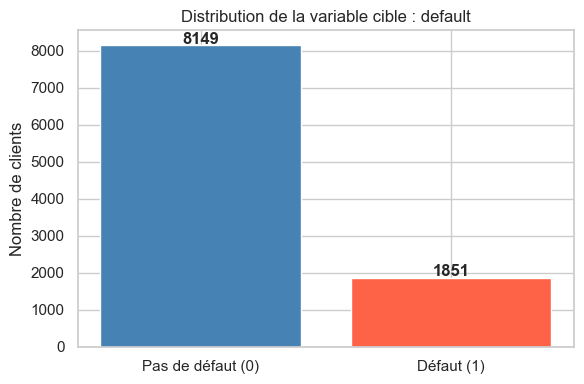

In [7]:
counts = df['default'].value_counts()
pct = df['default'].value_counts(normalize=True) * 100

print('Distribution de la cible :')
print(f'  Pas de défaut (0) : {counts[0]} clients ({pct[0]:.1f}%)')
print(f'  Défaut (1)        : {counts[1]} clients ({pct[1]:.1f}%)')

# Visualisation
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Pas de défaut (0)', 'Défaut (1)'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Distribution de la variable cible : default')
ax.set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
print('\nObservation : Le dataset est déséquilibré (~18.5% de défauts). À garder en tête pour le choix des métriques.')


Observation : Le dataset est déséquilibré (~18.5% de défauts). À garder en tête pour le choix des métriques.


## 7. Distribution des features numériques

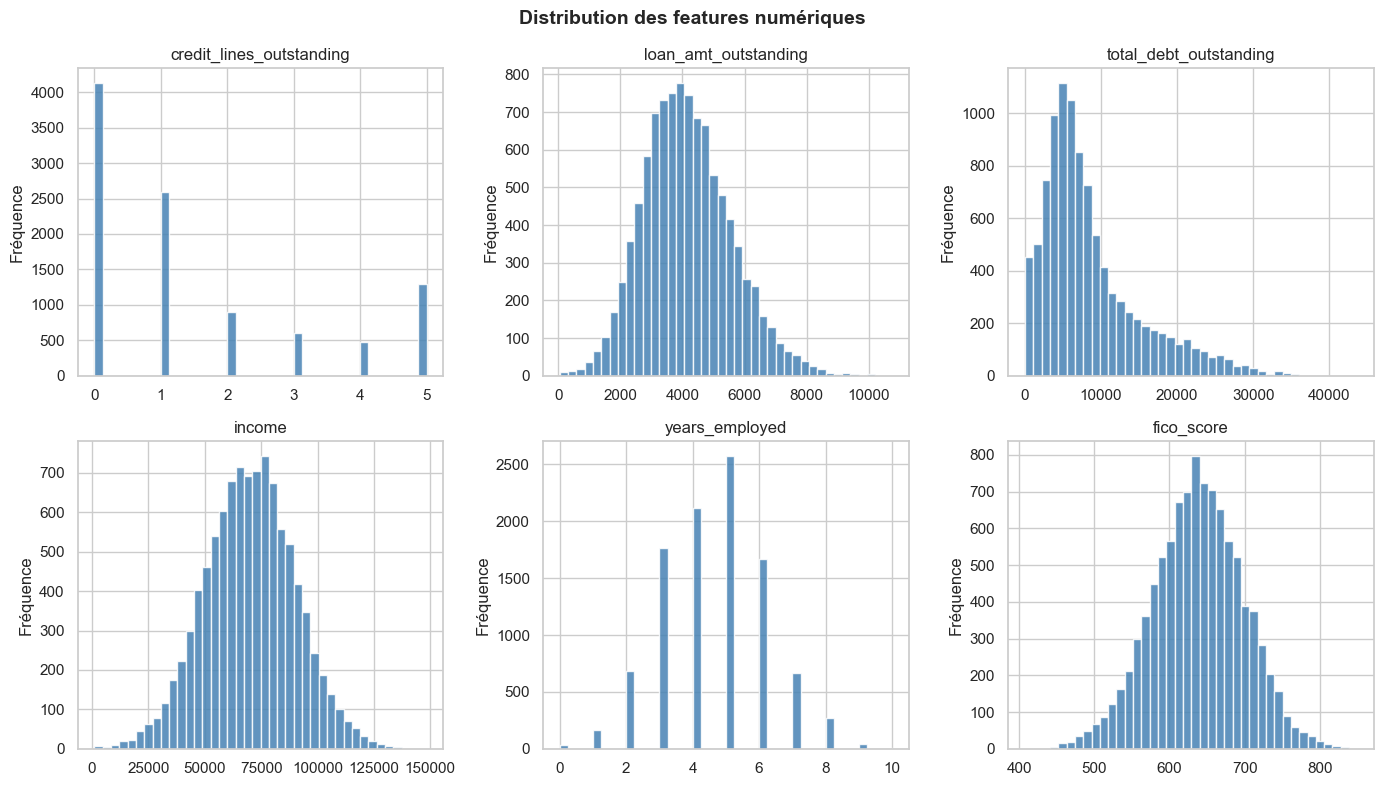

In [9]:
features = ['credit_lines_outstanding', 'loan_amt_outstanding', 
            'total_debt_outstanding', 'income', 'years_employed', 'fico_score']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des features numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Comparaison des features selon le défaut

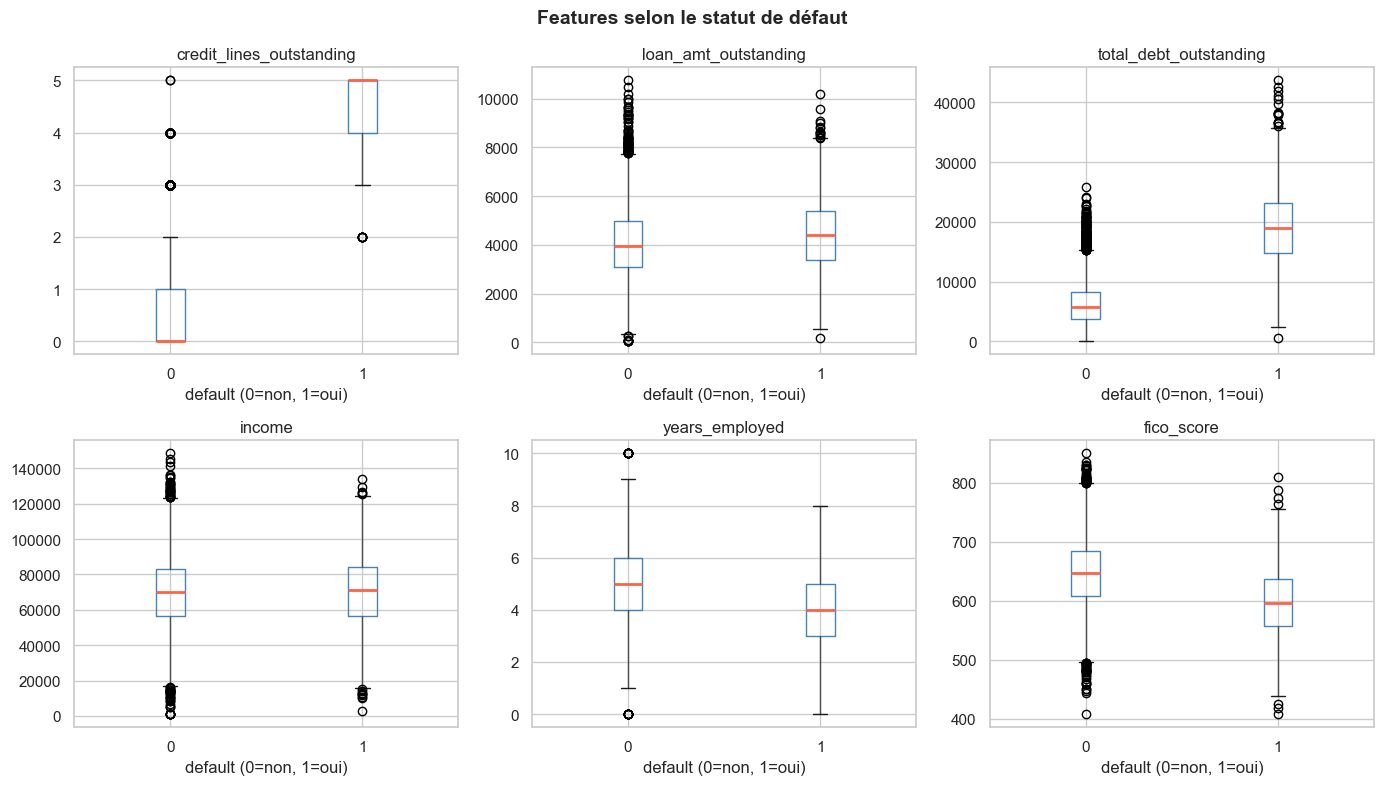

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='default', ax=axes[i], 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('default (0=non, 1=oui)')

plt.suptitle('Features selon le statut de défaut', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Matrice de corrélation

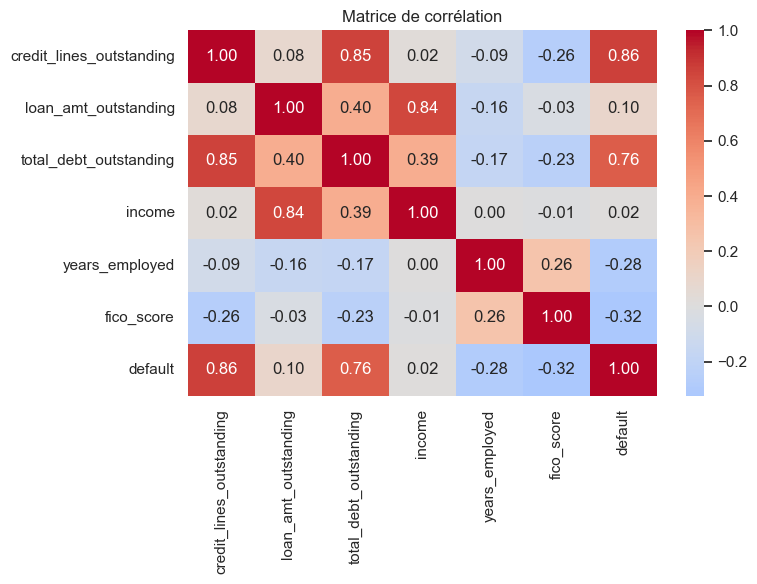

Corrélation avec la cible (default) :
default                     1.000000
credit_lines_outstanding    0.862815
total_debt_outstanding      0.758868
loan_amt_outstanding        0.098978
income                      0.016309
years_employed             -0.284506
fico_score                 -0.324515
Name: default, dtype: float64


In [11]:
corr = df[features + ['default']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.show()

print('Corrélation avec la cible (default) :')
print(corr['default'].sort_values(ascending=False))

## 10. Sélection des features & nettoyage final

In [12]:
# On supprime customer_id : identifiant unique, aucune valeur prédictive
df_clean = df.drop(columns=['customer_id'])

print('Colonnes finales :')
print(df_clean.columns.tolist())
print(f'\nShape finale : {df_clean.shape}')
df_clean.head()

Colonnes finales :
['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']

Shape finale : (10000, 7)


,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,0,5221.545193,3915.471226,78039.38546,5,605,0
1,5,1958.928726,8228.752520,26648.43525,2,572,1
2,0,3363.009259,2027.830850,65866.71246,4,602,0
3,0,4766.648001,2501.730397,74356.88347,5,612,0
4,1,1345.827718,1768.826187,23448.32631,6,631,0


In [13]:
# Vérification finale
print('Valeurs manquantes après nettoyage :')
print(df_clean.isnull().sum())
print(f'\nDoublons : {df_clean.duplicated().sum()}')

Valeurs manquantes après nettoyage :
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Doublons : 0


## 11. Export du dataset propre

In [14]:
df_clean.to_csv('../data/data_clean_features.csv', index=False)
print('✅ Fichier sauvegardé : data/data_clean_features.csv')
print(f'   {df_clean.shape[0]} lignes x {df_clean.shape[1]} colonnes')

✅ Fichier sauvegardé : data/data_clean_features.csv
   10000 lignes x 7 colonnes


## 12. Résumé

**Ce qui a été fait :**
- ✅ Exploration du dataset (10 000 lignes, 8 colonnes)
- ✅ Aucune valeur manquante ni doublon détecté
- ✅ Variable cible `default` : 18.5% de défauts (dataset déséquilibré)
- ✅ Suppression de `customer_id` (inutile pour le ML)
- ✅ Export de `data/data_clean_features.csv`

**Features retenues pour le ML :**
- `credit_lines_outstanding`
- `loan_amt_outstanding`
- `total_debt_outstanding`
- `income`
- `years_employed`
- `fico_score`

**Cible :** `default`

**Recommandation pour la suite :** Utiliser le recall ou le F1-score comme métrique principale (dataset déséquilibré, les faux négatifs — prêts à risque non détectés — sont coûteux pour la banque).